<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5.2 Middleware 2 - MTConnect Adapter

## 2.1 Multiple MTConnect Adapters

In this part, we will run multiple MTConnect adapters so that each adapter is responsible for each sensor data collection. The schematic of this case is shown in Figure 10. Because we will collect data from three different sensors with different sampling periods each, three adapters,[lab5_adapter2-1.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-1.py?raw=true), [lab5_adapter2-2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-2.py?raw=true), and [lab5_adapter2-3.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-3.py?raw=true), are needed.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig10.png?raw=true" width="100%">


*Figure 10 MTConnect configuration 2: Multiple adapter case*

Please follow the steps below.
1.	Halt MTConnect agent (Shortcut: Ctrl + c on the ‘Terminal’)
2.	Modify ‘agent.cfg’ file to have 3 adapters as Figure 11.

  a.	Please note that each adapter **MUST** have **different port number**.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig11.png?raw=true" width="70%">
  
  *Figure 11 ‘agent.cfg’ for multiple MTConnect adapters*

3.	Don’t modify ‘Device.xml’.

  a.	We will use the same as before.
4.	Run the agent again.

Now, we are ready to run the adapter.

### Task 2.1

1.	Modify each sample adapter program to make all complete to have all values available. And then run all the adapters.  

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.






  ---

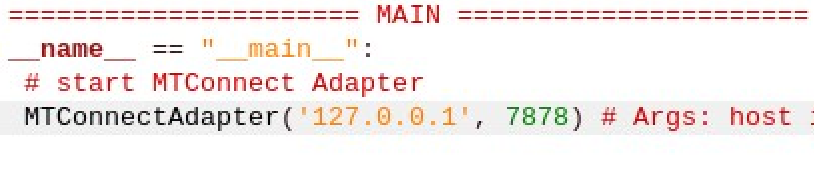


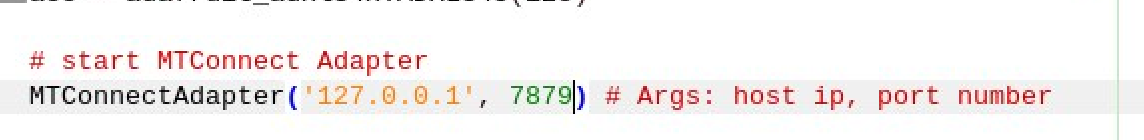


  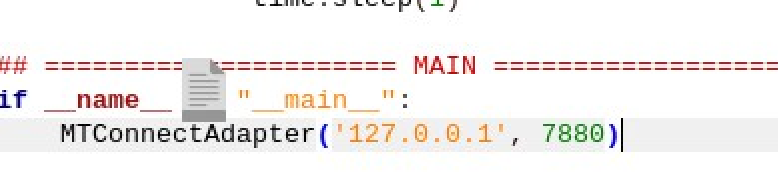
  ---

### Task 2.2
Place the entire Python code of each adapter to the report below in each appropiate section


In [ ]:
# ME597 Lab5용 MTConnect 어댑터 샘플
# 가상 습도 센서(랜덤 습도 값) 및 DS18B20 온도 센서 데이터 수집 코드

import sys
import time
import datetime
from data_item import Event, Sample  # data_item 패키지 로드
from mtconnect_adapter import Adapter  # mtconnect_adapter 패키지 로드

import os
import glob
import random

class MTConnectAdapter(object):  # MTConnect 어댑터 클래스

    def __init__(self, host, port):
        # MTConnect 어댑터 연결 정보 설정
        self.host = host
        self.port = port
        self.adapter = Adapter((host, port))

        # Samples (수치형 데이터) 설정
        self.t1 = Sample('t1')  # 't1' ID를 가지는 온도 샘플 생성
        self.adapter.add_data_item(self.t1)  # 어댑터에 t1 추가

        self.h1 = Sample('h1')  # 'h1' ID를 가지는 습도 샘플 생성
        self.adapter.add_data_item(self.h1)  # 어댑터에 h1 추가

        # Events (상태형 데이터) 설정 - 어댑터 가용 상태
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # MTConnect 시작
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()
        self.adapter_stream()

    def read_temp_raw(self):
        os.system('modprobe w1-gpio')
        os.system('modprobe w1-therm')
        base_dir = '/sys/bus/w1/devices/'
        device_folder = glob.glob(base_dir + '28*')[0]
        device_file = device_folder + '/w1_slave'
        f = open(device_file, 'r')
        lines = f.readlines()
        f.close()
        return lines

    def read_temp(self):
        lines = self.read_temp_raw()
        while lines[0].strip()[-3:] != 'YES':
            time.sleep(0.2)
            lines = self.read_temp_raw()
        equals_pos = lines[1].find('t=')
        if equals_pos != -1:
            temp_string = lines[1][equals_pos+2:]
            temp_c = float(temp_string) / 1000.0
            return temp_c

    def adapter_stream(self):
        while True:
            try:
                t1 = self.read_temp()  # 온도 측정
                h1 = random.uniform(50.0, 70.0)  # 습도 측정 (가상 데이터: 50% - 70%)

                now = datetime.datetime.now()  # 현재 시간 가져오기

                self.adapter.begin_gather()  # 데이터 수집 시작
                self.t1.set_value(str(t1))   # t1(온도) 데이터 값 설정
                self.h1.set_value(str(h1))   # h1(습도) 데이터 값 설정
                self.adapter.complete_gather()  # 데이터 수집 완료

                print("{} MTConnect data collection completed ... ".format(now))
                print("DS18B20: Temperature={}°C".format(t1))
                print("Virtual: Humidity={:.2f}RH%\n".format(h1))

                time.sleep(2)  # 2초 주기 (샘플링 주기)

            except KeyboardInterrupt:  # Ctrl + C 입력 시 중지
                print("Stopping MTConnect...")
                self.adapter.stop()
                sys.exit()

## ====================== MAIN ======================
if __name__ == "__main__":
    # 어댑터 1 실행 (포트: 7878)
    MTConnectAdapter('127.0.0.1', 7878)

In [ ]:
# ME597 Lab5용 MTConnect 어댑터 샘플
# ADXL345 가속도계 센서 데이터 수집 코드

import sys
import time
import datetime
from data_item import Event, Sample
from mtconnect_adapter import Adapter

import board
import busio
import adafruit_adxl34x

class MTConnectAdapter(object):

    def __init__(self, host, port):
        self.host = host
        self.port = port
        self.adapter = Adapter((host, port))

        # Samples 설정 (X, Y, Z축 가속도)
        self.a1 = Sample('a1')  # X축 가속도
        self.adapter.add_data_item(self.a1)

        self.a2 = Sample('a2')  # Y축 가속도
        self.adapter.add_data_item(self.a2)

        self.a3 = Sample('a3')  # Z축 가속도
        self.adapter.add_data_item(self.a3)

        # Events 설정 (가용 상태)
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # MTConnect 시작
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()
        self.adapter_stream()

    def adapter_stream(self):
        while True:
            try:
                a = acc.acceleration  # (X, Y, Z) 가속도 튜플 가져오기
                a1 = a[0]  # X축 가속도
                a2 = a[1]  # Y축 가속도
                a3 = a[2]  # Z축 가속도

                now = datetime.datetime.now()

                self.adapter.begin_gather()

                self.a1.set_value(str(a1))  # X축 값 설정
                self.a2.set_value(str(a2))  # Y축 값 설정
                self.a3.set_value(str(a3))  # Z축 값 설정

                self.adapter.complete_gather()

                print("{} MTConnect data collection completed ... ".format(now))
                print("ADXL345: Xacc={:.2f}, Yacc={:.2f}, Zacc={:.2f} m/s^2\n".format(a1, a2, a3))

                time.sleep(1)  # 1초 주기 (샘플링 주기)

            except KeyboardInterrupt:
                print("Stopping MTConnect...")
                self.adapter.stop()
                sys.exit()

## ====================== MAIN ======================
if __name__ == "__main__":
    # I2C 통신 및 핀 설정
    i2c = busio.I2C(board.SCL, board.SDA)

    # ADXL345 객체 생성
    acc = adafruit_adxl34x.ADXL345(i2c)

    # 어댑터 2 실행 (포트: 7879)
    MTConnectAdapter('127.0.0.1', 7879)

In [ ]:
# ME597 Lab5용 MTConnect 어댑터 샘플
# 전력계(Power Meter) 데이터 수집 코드

import sys
import time
import datetime
from data_item import Event, Sample
from mtconnect_adapter import Adapter

class MTConnectAdapter(object):

    def __init__(self, host, port):
        self.host = host
        self.port = port
        self.adapter = Adapter((host, port))

        # Samples 설정 (전력 데이터)
        self.p1 = Sample('p1')
        self.adapter.add_data_item(self.p1)

        # Events 설정
        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        # MTConnect 시작
        self.adapter.start()
        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()
        self.adapter_stream()

    def read_power(self):
        # 실제 전력계 측정 로직 또는 센서 데이터 연동 함수
        return 120.5  # 예시 수치

    def adapter_stream(self):
        while True:
            try:
                p1 = self.read_power()
                now = datetime.datetime.now()

                self.adapter.begin_gather()
                self.p1.set_value(str(p1))
                self.adapter.complete_gather()

                print("{} MTConnect data collection completed ... ".format(now))
                print("Power Meter: Power={} W\n".format(p1))

                time.sleep(1)

            except KeyboardInterrupt:
                print("Stopping MTConnect...")
                self.adapter.stop()
                sys.exit()

## ====================== MAIN ======================
if __name__ == "__main__":
    # 어댑터 3 실행 (모든 IP 접근 허용 및 포트: 7880)
    MTConnectAdapter('0.0.0.0', 7880)

### Task 2.3

1.	On your laptop, run the MTConnect adapter for the power meter.

  * Please keep running MTConnect adapters for DS18B20 and ADXL345 on Raspberry Pi.
  
  * Hint:
        * You need to change ‘agent.cfg’ file.
        * You need to run the adapter Python code for power meter on laptop.
        * If it does not work, please check Windows firewall.

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.





  ---
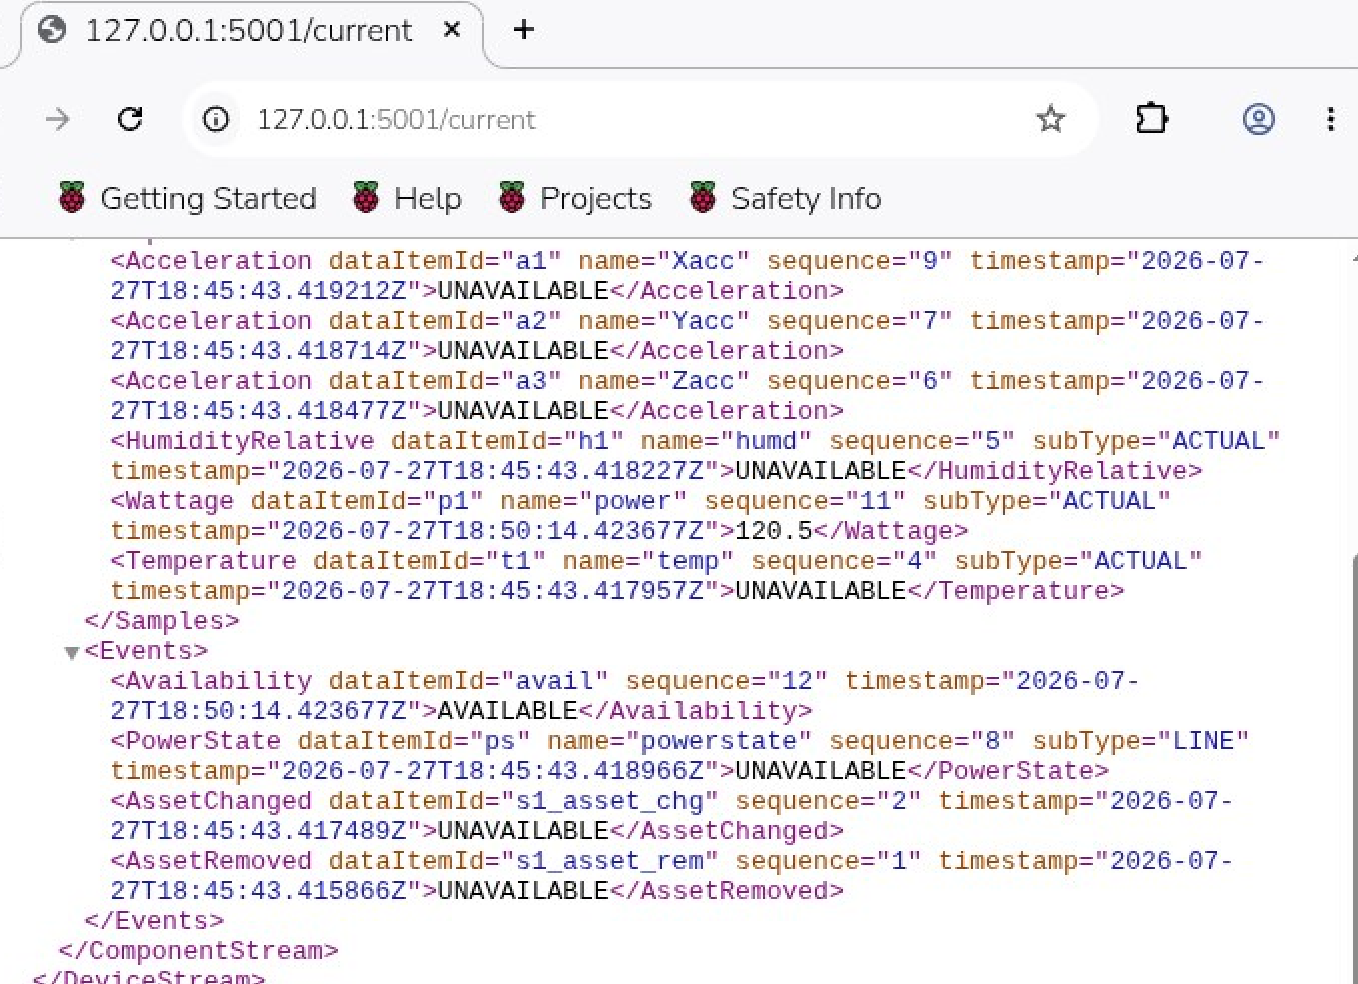
  ---

  3. In the text bock below, place changed parts in 'agent.cfg'.



---

```
Devices = Device.xml
Port = 5001
AllowPut = true
ReconnectInterval = 1000
BufferSize = 17
MonitorConfigFiles = true
Pretty = false
SchemaVersion = 1.5

Adapters {
   # Log file has all machines with device name prefixed
   Adapter1 {
      Host = 127.0.0.1
      Port = 7878
   }
   Adapter2 {
      Host = 127.0.0.1
      Port = 7879
   }
   Adapter3 {
      Host = 10.186.61.255
      Port = 7880
   }
}

#Files {
#    schemas {
#        Path = ./schemas
#        Location = /schemas/
#    }
#    styles {
#        Path = ./styles
#        Location = /styles/
#    }
#    Favicon {
#        Path = ./styles/favicon.ico
#        Location = /favicon.ico
#    }
#}
#
#StreamsStyle {
#  Location = /styles/Streams.xsl
#}
#
# Logger Configuration
logger_config
{
    logging_level = debug
    output = cout
}

```

---



  4. Discuss what changes were made.

  ---

p1 항목이 업데이트 되어 나타난다. 2.1에서는 라즈베리파이 내부에서 3개의 어댑터가 로컬에서 값이 모두 수집되었으나, 2.3 이후로는 노트북에서 전송한 센서 데이터가 MTConnect로 전달된다.

  ---

Please keep your MTConnect stream working to perform the following Part (5.3).

<br></br>

Please continue to [Lab 5.3 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab3.ipynb).
